# Notebook 7 - Financial Impact and Intervention Targeting

**Goal** - attach revenue figures to churn scores, model three retention scenarios, and identify the 81k subscribers worth targeting with a free-month offer.

All figures in TWD. Monthly subscription price: 149 TWD.

## Load scored subscribers

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

PROCESSED = Path(r"C:\kkbox-retention-analytics\data\processed")

scored = pd.read_csv(PROCESSED / "master_scored.csv")
master = pd.read_csv(PROCESSED / "master.csv",
                     usecols=['msno', 'total_paid', 'avg_plan_duration'])

df = scored.merge(master, on='msno', how='left')

print(f"Rows: {df.shape[0]:,}")
print(f"Nulls in total_paid: {df['total_paid'].isnull().sum():,}")
print(f"\nRevenue summary:")
print(df['total_paid'].describe().round(2))

Rows: 1,082,190
Nulls in total_paid: 0

Revenue summary:
count    1082190.00
mean        2276.60
std         1309.83
min            0.00
25%         1188.00
50%         1980.00
75%         3427.00
max        17433.00
Name: total_paid, dtype: float64


## Historical revenue at risk

Probability-weighted by total lifetime spend. Useful for segment profiling.

In [8]:
df['revenue_at_risk'] = df['churn_probability'] * df['total_paid']

total_revenue    = df['total_paid'].sum()
total_at_risk    = df['revenue_at_risk'].sum()
high_risk        = df[df['churn_probability'] > 0.7]

print(f"Total historical revenue:       TWD {total_revenue:>15,.0f}")
print(f"Expected revenue at risk:       TWD {total_at_risk:>15,.0f}")
print(f"At-risk share of total revenue: {total_at_risk / total_revenue:.1%}")
print(f"\nHigh-risk subscribers (>0.7):   {len(high_risk):,}")
print(f"Revenue concentrated in high-risk users {high_risk['total_paid'].sum():,.0f}")
print(f"High-risk share of total revenue: {high_risk['total_paid'].sum() / total_revenue:.1%}")

Total historical revenue:       TWD   2,463,713,303
Expected revenue at risk:       TWD     415,228,174
At-risk share of total revenue: 16.9%

High-risk subscribers (>0.7):   145,143
Revenue concentrated in high-risk users 276,150,757
High-risk share of total revenue: 11.2%


## Monthly forward-looking revenue at risk


In [6]:
df['revenue_at_risk_monthly'] = df['churn_probability'] * 149

total_monthly   = df['revenue_at_risk_monthly'].sum()
high_risk_monthly = df[df['churn_probability'] > 0.7]['revenue_at_risk_monthly'].sum()

print(f"Monthly revenue at risk (all):       TWD {total_monthly:>12,.0f}")
print(f"Monthly revenue at risk (high risk): TWD {high_risk_monthly:>12,.0f}")
print(f"High-risk share of monthly at risk:  {high_risk_monthly / total_monthly:.1%}")

Monthly revenue at risk (all):       TWD   30,274,108
Monthly revenue at risk (high risk): TWD   19,384,573
High-risk share of monthly at risk:  64.0%


## Campaign parameters

Free month offered to all 145k high-risk subscribers. 80% acceptance rate assumed.

Two cost models run in parallel:
- **Operating cost** - marginal cost to deliver one month of streaming (~40 TWD)
- **Foregone revenue** - full retail price of the free month (149 TWD)


In [12]:
# ALL NUMBERS IN TWD
MONTHLY_PRICE             = 149
CONTACT_COST              = 5
ACCEPTANCE_RATE           = 0.80
OPERATING_COST_FREE_MONTH = 40
FOREGONE_REV_FREE_MONTH   = MONTHLY_PRICE

contacts     = len(high_risk_df)
accepters    = int(contacts * ACCEPTANCE_RATE)
non_accepters = contacts - accepters

contact_total          = contacts * CONTACT_COST
free_month_op          = accepters * OPERATING_COST_FREE_MONTH
free_month_fr          = accepters * FOREGONE_REV_FREE_MONTH

total_cost_op = contact_total + free_month_op
total_cost_fr = contact_total + free_month_fr

print(f"Subscribers contacted:          {contacts:,}")
print(f"Expected accepters (80%):       {accepters:,}")
print(f"Expected non-accepters (20%):   {non_accepters:,}")
print(f"Contact cost (all):         TWD {contact_total:>12,.0f}")
print(f"\nModel A — Operating cost (40 TWD per free month):")
print(f"Free month cost:            TWD {free_month_op:>12,.0f}")
print(f"Total campaign cost:        TWD {total_cost_op:>12,.0f}")
print(f"\nModel B — Foregone revenue (149 TWD per free month):")
print(f"Free month cost:            TWD {free_month_fr:>12,.0f}")
print(f"Total campaign cost:        TWD {total_cost_fr:>12,.0f}")

Subscribers contacted:          145,143
Expected accepters (80%):       116,114
Expected non-accepters (20%):   29,029
Contact cost (all):         TWD      725,715

Model A — Operating cost (40 TWD per free month):
Free month cost:            TWD    4,644,560
Total campaign cost:        TWD    5,370,275

Model B — Foregone revenue (149 TWD per free month):
Free month cost:            TWD   17,300,986
Total campaign cost:        TWD   18,026,701


## Retention scenarios

In [14]:
scenarios = {'Low': 0.8, 'Base': 2, 'High': 4.0}

header = f"{'Scenario':<8} {'Months':>7} {'Revenue':>14} {'Net (Op.)':>14} {'ROI (Op.)':>10} {'Net (Foregone)':>16} {'ROI (Foregone)':>15}"
print(header)
print("-" * 88)

for name, months in scenarios.items():
    revenue    = accepters * MONTHLY_PRICE * months
    net_op     = revenue - total_cost_op
    net_fr     = revenue - total_cost_fr
    roi_op     = net_op / total_cost_op
    roi_fr     = net_fr / total_cost_fr

    print(f"{name:<8} {months:>7.2f} {revenue:>14,.0f} {net_op:>14,.0f} {roi_op:>9.2f}x {net_fr:>16,.0f} {roi_fr:>14.2f}x")

Scenario  Months        Revenue      Net (Op.)  ROI (Op.)   Net (Foregone)  ROI (Foregone)
----------------------------------------------------------------------------------------
Low         0.80     13,840,789      8,470,514      1.58x       -4,185,912          -0.23x
Base        2.00     34,601,972     29,231,697      5.44x       16,575,271           0.92x
High        4.00     69,203,944     63,833,669     11.89x       51,177,243           2.84x


## Break-even chart - revenue curve vs two cost lines

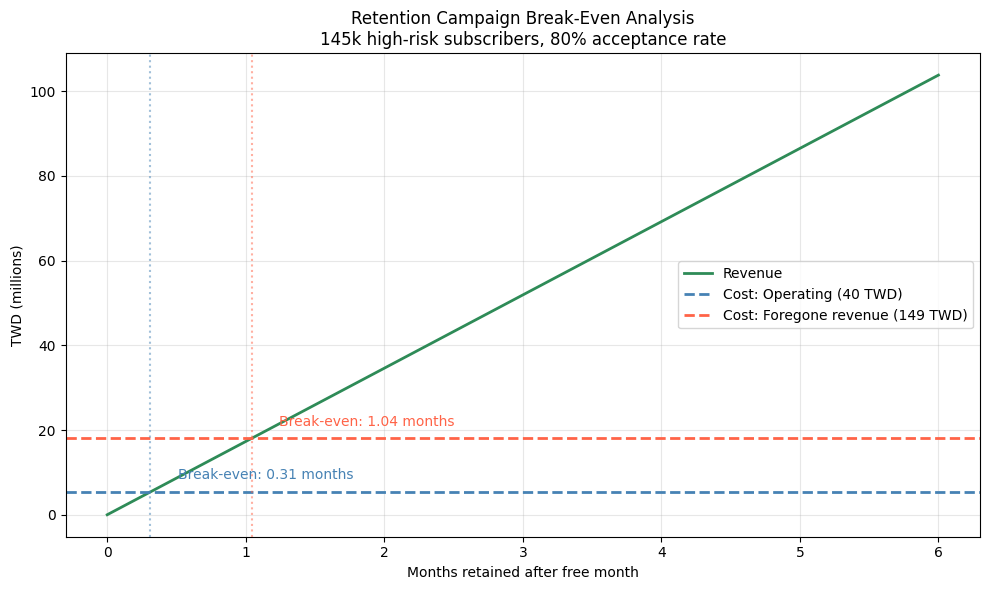

Break-even (Operating cost):   0.31 months
Break-even (Foregone revenue): 1.04 months


In [15]:
import matplotlib.pyplot as plt

months_range = np.linspace(0, 6, 300)
revenue_curve = accepters * MONTHLY_PRICE * months_range

breakeven_op = total_cost_op / (accepters * MONTHLY_PRICE)
breakeven_fr = total_cost_fr / (accepters * MONTHLY_PRICE)

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(months_range, revenue_curve / 1e6, label='Revenue', color='seagreen', linewidth=2)
ax.axhline(total_cost_op / 1e6, color='steelblue', linewidth=2, linestyle='--', label='Cost: Operating (40 TWD)')
ax.axhline(total_cost_fr / 1e6, color='tomato', linewidth=2, linestyle='--', label='Cost: Foregone revenue (149 TWD)')

ax.axvline(breakeven_op, color='steelblue', linestyle=':', alpha=0.5)
ax.axvline(breakeven_fr, color='tomato', linestyle=':', alpha=0.5)

ax.annotate(f'Break-even: {breakeven_op:.2f} months',
            xy=(breakeven_op, total_cost_op / 1e6),
            xytext=(breakeven_op + 0.2, total_cost_op / 1e6 + 3),
            color='steelblue', fontsize=10)
ax.annotate(f'Break-even: {breakeven_fr:.2f} months',
            xy=(breakeven_fr, total_cost_fr / 1e6),
            xytext=(breakeven_fr + 0.2, total_cost_fr / 1e6 + 3),
            color='tomato', fontsize=10)

ax.set_xlabel('Months retained after free month')
ax.set_ylabel('TWD (millions)')
ax.set_title('Retention Campaign Break-Even Analysis\n145k high-risk subscribers, 80% acceptance rate')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Break-even (Operating cost):   {breakeven_op:.2f} months")
print(f"Break-even (Foregone revenue): {breakeven_fr:.2f} months")



## Identify persuadable subscribers

Highest-risk subscribers are not the best targets. A subscriber dormant for 11 months will not be saved by a free month offer. We filter for recently active subscribers with low dormancy — genuinely persuadable.

In [16]:
master_fe = pd.read_csv(PROCESSED / "master_fe.csv")
df_full = df.merge(master_fe.drop(columns=['is_churn']), on='msno', how='left')

high_risk = df_full[df_full['churn_probability'] > 0.7].copy()

cancel_threshold   = high_risk['cancel_rate'].median()
recency_threshold  = 0.7
dormancy_threshold = high_risk['dormancy_risk'].quantile(0.75)

persuadable = high_risk[
    (high_risk['cancel_rate']    < cancel_threshold) &
    (high_risk['recency_ratio']  < recency_threshold) &
    (high_risk['dormancy_risk']  < dormancy_threshold)
].copy()

persuadable = persuadable.sort_values('churn_probability', ascending=False)

cols_to_save = ['msno', 'churn_probability', 'cancel_rate',
                'recency_ratio', 'dormancy_risk', 'plan_commitment']

persuadable[cols_to_save].to_csv(PROCESSED / "intervention_list.csv", index=False)

print(f"High-risk subscribers:      {len(high_risk):,}")
print(f"Persuadable segment:        {len(persuadable):,}")
print(f"Filtered out (lost causes): {len(high_risk) - len(persuadable):,}")
print(f"\nThresholds used:")
print(f"  cancel_rate   < {cancel_threshold:.3f}  (median of high-risk group)")
print(f"  recency_ratio < {recency_threshold}    (not completely dormant)")
print(f"  dormancy_risk < {dormancy_threshold:.1f}  (75th percentile of high-risk group)")

High-risk subscribers:      145,143
Persuadable segment:        0
Filtered out (lost causes): 145,143

Thresholds used:
  cancel_rate   < 0.000  (median of high-risk group)
  recency_ratio < 0.7    (not completely dormant)
  dormancy_risk < 16.0  (75th percentile of high-risk group)


In [17]:
recency_threshold  = high_risk['recency_ratio'].quantile(0.75)
dormancy_threshold = high_risk['dormancy_risk'].quantile(0.75)

persuadable = high_risk[
    (high_risk['recency_ratio'] < recency_threshold) &
    (high_risk['dormancy_risk'] < dormancy_threshold)
].copy()

persuadable = persuadable.sort_values('churn_probability', ascending=False)
persuadable[cols_to_save].to_csv(PROCESSED / "intervention_list.csv", index=False)

print(f"High-risk subscribers:      {len(high_risk):,}")
print(f"Persuadable segment:        {len(persuadable):,}")
print(f"Filtered out (lost causes): {len(high_risk) - len(persuadable):,}")
print(f"\nThresholds used:")
print(f"  recency_ratio < {recency_threshold:.3f}  (75th percentile of high-risk group)")
print(f"  dormancy_risk < {dormancy_threshold:.1f}  (75th percentile of high-risk group)")

High-risk subscribers:      145,143
Persuadable segment:        81,253
Filtered out (lost causes): 63,890

Thresholds used:
  recency_ratio < 0.058  (75th percentile of high-risk group)
  dormancy_risk < 16.0  (75th percentile of high-risk group)


## Conclusion

16.9% of total historical revenue sits with high-risk subscribers. Monthly forward exposure: 30.3M TWD.

Break-even at 0.31 months (operating cost model) and 1.04 months (foregone revenue model). Profitability depends more on which accounting treatment you use than on model performance.

81,253 persuadable subscribers identified. 63,890 excluded as likely lost causes.

True uplift requires a randomised holdout. Without one, conversion rates are model predictions, not measured campaign effect.
